# **IAPR26: UNO Vision Challenge**


**Group Name :** 

**Author 1 (sciper):** Arno Douady (326395)  
**Author 2 (sciper):** Nicolas Robson (325334)   
**Author 3 (sciper):** Johanne Pinel (324707)   

**Release date:** 24.04.2026   
**Due date:** 20.05.2026 (11:55 pm)


In [2]:
# From past Labs

from skimage.color import rgb2hsv
from skimage.morphology import closing, opening, disk, remove_small_holes, remove_small_objects, binary_dilation
from skimage.transform import rotate, resize, AffineTransform, warp
from sklearn.metrics.pairwise import euclidean_distances
from skimage.measure import regionprops
import matplotlib.image as mpimg


import os
import copy
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from src.Project_utils import *

from sklearn.metrics import accuracy_score, f1_score

In [3]:
# Check dans quel dossier on est
print(os.getcwd())

c:\Users\Johanne\Desktop\EPFL\MA4\Image pattern\iapr2026\Project


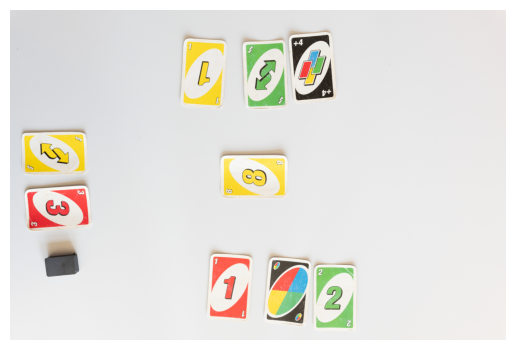

In [20]:
# Printer une image
img = mpimg.imread("data/iapr-26-uno-vision-challenge/train_images/L1000773.jpg")

plt.imshow(img)
plt.axis("off")
plt.show()

## Fist step : Segmentation

Extraire les cartes --> hmmm peut être faire 5 images : une pour le jaune, une pour le rouge, une pour le bleu et une pour le vert et une dernière pour le noir ?

In [ ]:
def extract_hsv_channels(img):
    """
    Extract HSV channels from the input image.

    """
    # Get the shape of the input image
    M, N, C = np.shape(img)

    # Define default values for HSV channels
    data_h = np.zeros((M, N))
    data_s = np.zeros((M, N))
    data_v = np.zeros((M, N))

    data_hsv = rgb2hsv(img)
    data_h = data_hsv[:, :, 0]
    data_s = data_hsv[:, :, 1]
    data_v = data_hsv[:, :, 2]

    return data_h, data_s, data_v

In [ ]:
def apply_hsv_threshold(img, h_thresh=0.01, s_thresh=0.1, v_thresh=0.1):
    """
    Apply threshold to the input image in hsv colorspace.

    Args
    ----
    img: np.ndarray (M, N, C)
        Input image of shape MxN and C channels.
    h_thresh: float
        Hue value threshold
    s_thresh: float
        Saturation value threshold
    v_thresh: float
        Value threshold
    
    Return
    ------
    img_th: np.ndarray (M, N)
        Thresholded image.
    """

    # Define the default value for the input image
    M, N, C = np.shape(img)
    img_th = np.zeros((M, N))

    # Use the previous function to extract HSV channels
    data_h, data_s, data_v = extract_hsv_channels(img=img)
    
    img_th = (data_h > h_thresh) & (data_s > s_thresh) & (data_v > v_thresh)
    
    return  img_th

    

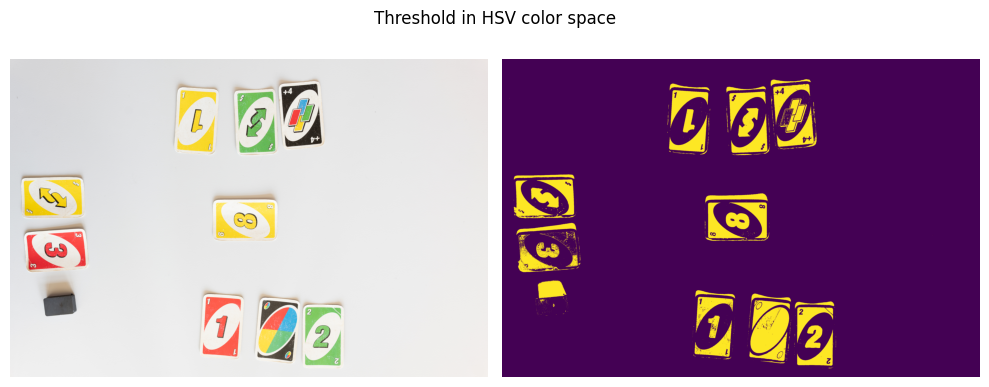

In [32]:
img_th=apply_hsv_threshold(img)
plot_thresholded_image(img=img, func=apply_hsv_threshold, title="Threshold in HSV color space")

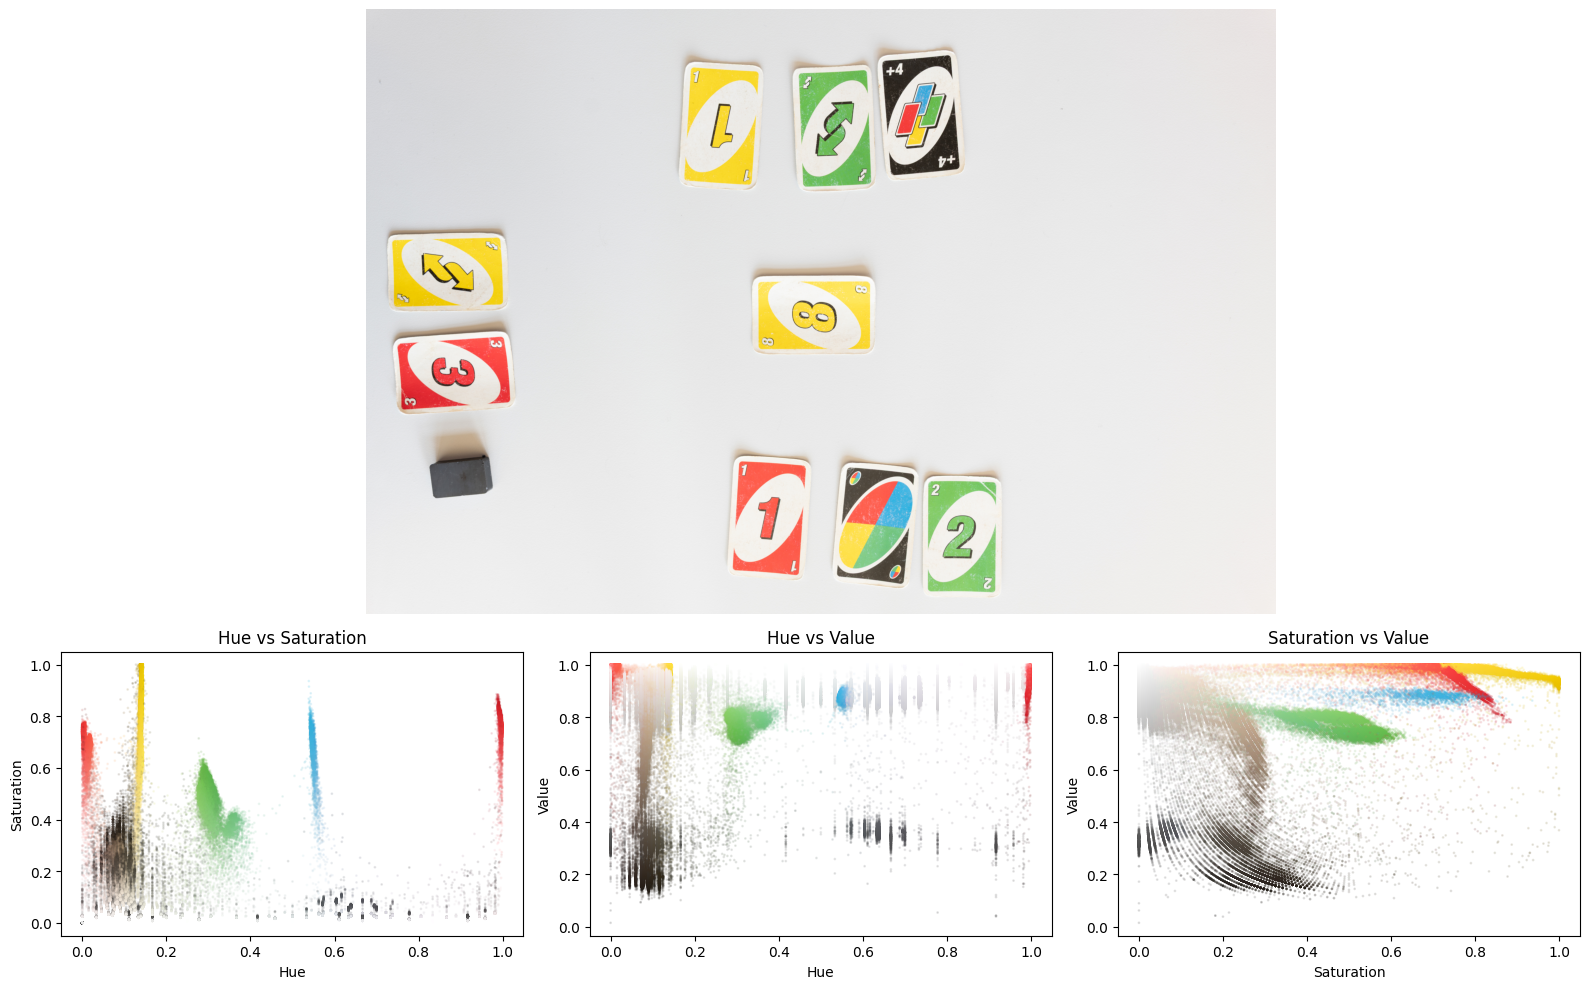

In [26]:
plot_colors_histo(
    img = img,
    func = extract_hsv_channels,
    labels = ["Hue", "Saturation", "Value"],
)

### Faire comme dernier exo du lab 1 pour décomposer les différents éléments

Est-ce que avoir le channel en noir --> avoir direct la position du joueur/joueuse ?


Du coup pour la segmentation : choix RGB ou HSV --> on voit que c'est beaucoup mieux HSV pour décomposer les couleurs GO faire ça

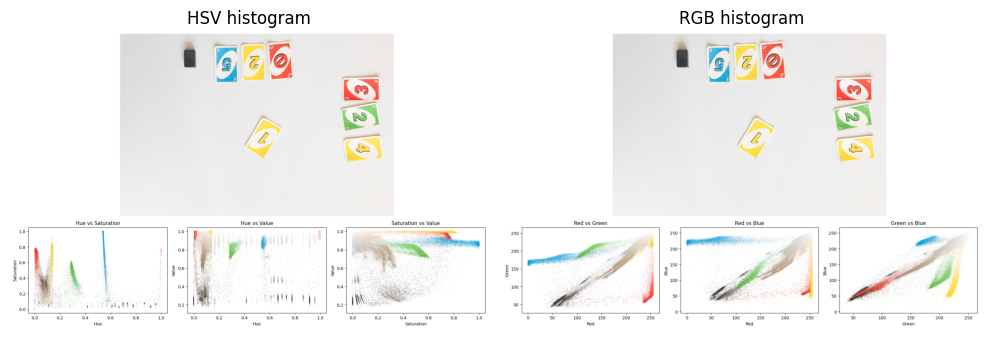

In [ ]:
img1 = mpimg.imread("Rapport/output_HSV.png")
img2 = mpimg.imread("Rapport/output_RGB.png")

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img1)
axes[0].axis("off")
axes[0].set_title("HSV histogram")

axes[1].imshow(img2)
axes[1].axis("off")
axes[1].set_title("RGB histogram")

plt.tight_layout()
plt.show()

In [ ]:
def remove_objects(img_th, size):
    """
    Remove objects from input image that are smaller than size argument.

    Args
    ----
    img_th: np.ndarray (M, N)
        Image mask of size MxN.
    size: int
        Minimal size of objects

    Return
    ------
    img_obj: np.ndarray (M, N)
        Image after remove small objects operation
    """

    # Define default value for input image
    img_obj = np.zeros_like(img_th)

    img_obj = remove_small_objects(img_th, min_size=size)


    return img_obj




In [38]:
def apply_hsv_threshold_v2(img, mode="red"):
    """
    Apply interval-based HSV thresholding for specific colors.

    Args
    ----
    img: np.ndarray (M, N, C)
        Input image of shape MxN and C channels.
    mode: str
        One of: "red", "blue", "yellow", "green", "black"

    Return
    ------
    img_th: np.ndarray (M, N)
        Binary thresholded image.
    """

    M, N, C = np.shape(img)

    data_h, data_s, data_v = extract_hsv_channels(img=img)

    if mode == "red":
        h_min1, h_max1 = 0.0, 0.05
        h_min2, h_max2 = 0.95, 1.0
        s_min, s_max = 0.4, 1.0
        v_min, v_max = 0.3, 1.0
        img_th = (
            (((data_h >= h_min1) & (data_h <= h_max1)) | 
             ((data_h >= h_min2) & (data_h <= h_max2))) &
            (data_s > s_min) & (data_s < s_max) &
            (data_v > v_min) & (data_v < v_max)
        )
        return img_th

    if mode == "blue":
        h_min, h_max = 0.52, 0.68
        s_min, s_max = 0.3, 1.0
        v_min, v_max = 0.3, 1.0

    if mode == "yellow":
        h_min, h_max = 0.06, 0.20
        s_min, s_max = 0.4, 1.0
        v_min, v_max = 0.4, 1.0

    if mode == "green":
        # Vert : Hue ~0.25-0.45
        h_min, h_max = 0.22, 0.48
        s_min, s_max = 0.3, 1.0
        v_min, v_max = 0.3, 1.0

    if mode == "black":
        h_min, h_max = 0.0, 1.0  
        s_min, s_max = 0.0, 1.0 
        v_min, v_max = 0.0, 0.35  

    img_th = (
        (data_h > h_min) & (data_h < h_max) &
        (data_s > s_min) & (data_s < s_max) &
        (data_v > v_min) & (data_v < v_max)
    )

    return img_th


def find_area_by_type(
    img: np.ndarray,
    mode: str = "red",
    visualize_hsv: bool = False,
    visualize_mask: bool = False,
    disk_size: int = 3,
    object_min_size: int = 30,
):

    if visualize_hsv:
        plot_colors_histo(
            img=img,
            func=extract_hsv_channels,
            labels=["Hue", "Saturation", "Value"],
        )

    img_th = apply_hsv_threshold_v2(img, mode=mode)

    if visualize_mask:
        plot_thresholded_image(
            img=img,
            func=lambda img: apply_hsv_threshold_v2(img, mode=mode),
            title=f"{mode.capitalize()} detection in HSV space"
        )

    out_mask = remove_small_objects(img_th, min_size=object_min_size)

    return out_mask

C:\Users\Johanne\AppData\Local\Temp\ipykernel_9212\2706125163.py:90: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  out_mask = remove_small_objects(img_th, min_size=object_min_size)


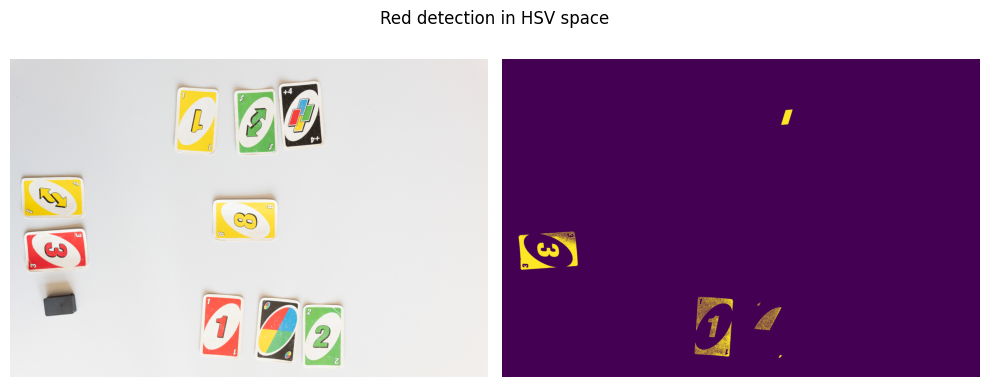

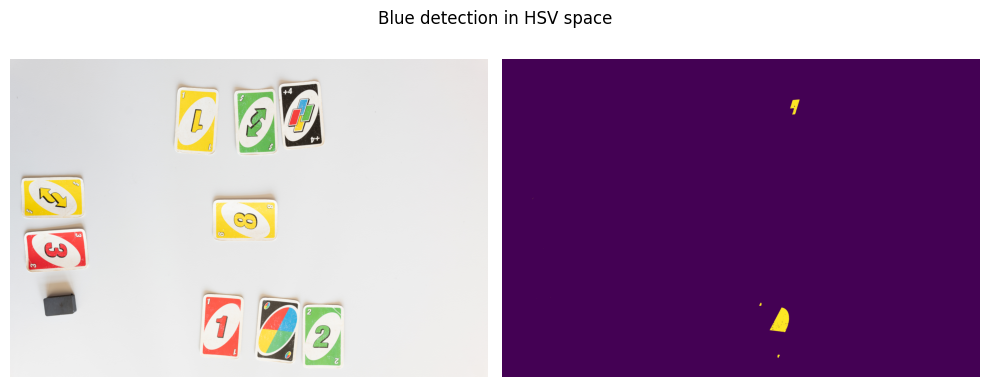

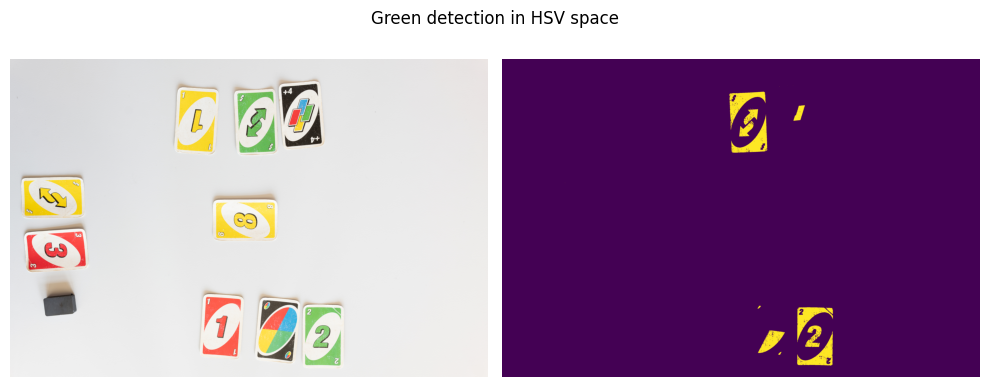

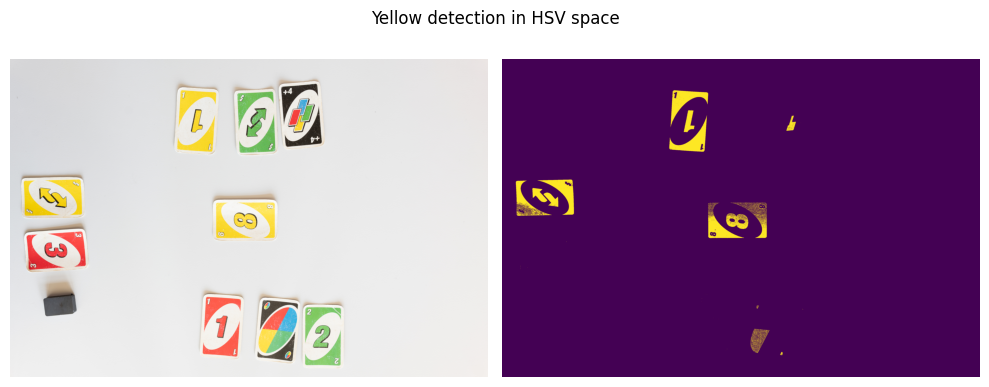

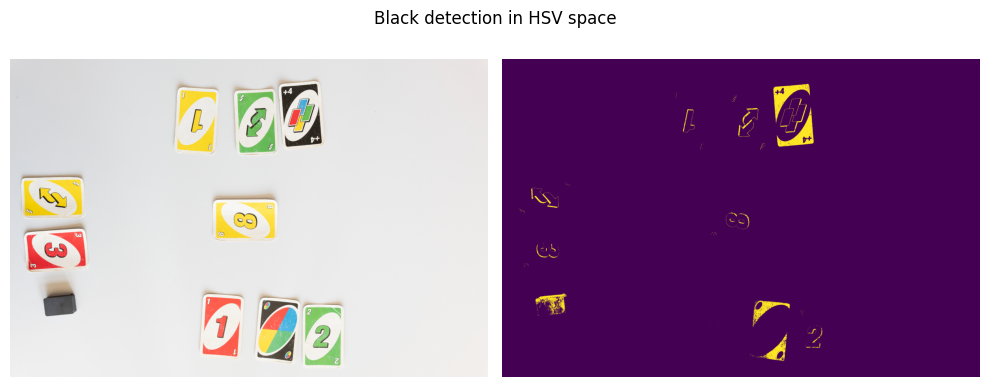

In [39]:
M, N, C= np.shape(img)
mask_red = np.zeros((M, N))
mask_blue = np.zeros((M, N))


mask_red = find_area_by_type(img, mode="red", visualize_mask=True)
mask_blue = find_area_by_type(img, mode="blue", visualize_mask=True)
mask_green = find_area_by_type(img, mode="green", visualize_mask=True)
mask_yellow = find_area_by_type(img, mode="yellow", visualize_mask=True)
mask_black = find_area_by_type(img, mode="black", visualize_mask=True)